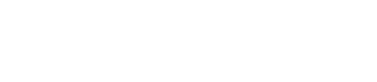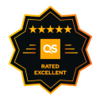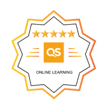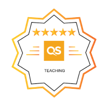

# Machine Learning I · Sesión 4 · Diseño experimental, desbalance, fuga de información, Pipeline y ColumnTransformer

**Universidad EAN · Facultad de Ingeniería · Posgrado**

*Profesor:* Jaime Alberto Ochoa Durán

*Profesor en Inteligencia Artificial · Facultad de Ingeniería*

🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)

## Trazabilidad de la sesión · Session traceability

| Campo | Valor |
|---|---|
| Unidad y código | Machine Learning I · IMVN0004 |
| Programa y modalidad | Especialización en Machine Learning · Maestría en Ciencia de Datos · Maestría en Gerencia en Inteligencia Artificial · Presencial |
| Módulo · Sesión | M1, Fundamentos, metodología y preparación · Sesión 4 de 18, cierre del módulo |
| Hilo conductor | Fórmula 1: Aditivo del combustible, La carrera y Trampa de escudería entran; Combustible se cierra |
| Conjunto de datos | Mismo extracto 2019 de siniestros viales de Bogotá, 32 962 filas (Secretaría Distrital de Movilidad, 2021), reconstruido en este cuaderno |
| Fase CRISP-DM | Preparación de los datos |
| Resultado de aprendizaje | Evaluar si un flujo de preparación, encapsulado en un Pipeline, está libre de fuga en cada partición y en cada pliegue de validación cruzada |
| Evidencia | Reto acumulativo R4, consolidación del Módulo 1 |
| Nivel cognitivo | Evaluar |
| Tiempo | 30 min de ejecución guiada, versión comprimida · Reto R4: 2,25 h autónomas |
| Lenguaje y versión | Python 3.11 · pandas, numpy, scikit-learn, imbalanced-learn |


## Cómo se trabaja este cuaderno · How to work this notebook

1. Responda cada 🎯 y cada 🔮 **antes** de abrir la solución plegada. Abrirla primero convierte el ejercicio en lectura, no en práctica.
2. Ejecute las celdas en orden. Varias secciones dependen del estado que deja la anterior.
3. Esta sesión cierra el Módulo 1: su ruta es más breve que las anteriores porque la Evaluación de Módulo ocupa 40 minutos de la clase.

## Estructura del cuaderno · Notebook structure

| # | Sección | Marca dominante |
|---|---|---|
| 1 | Recuperar el extracto y la partición de la Sesión 3 | 🔮 Predice antes de ejecutar |
| 2 | Encapsular en un Pipeline con ColumnTransformer | 🎯 Ejercicio rápido |
| 3 | Fuga dentro de la validación cruzada | 🕵️ Error silencioso 1 |
| 4 | Sobremuestreo sintético con SMOTE, solo en entrenamiento | 🕵️ Error silencioso 2 · 🩺 Depuración guiada · 🌐 Exercise in English |
| 5 | El conjunto de prueba se toca una sola vez | 💼 Reto de Negocio |
| 6 | Síntesis: cierre del Módulo 1 | 💼 Reto de Negocio de cierre |


## Marcas del cuaderno · Notebook marks

| Marca | Significado |
|---|---|
| 🔁 Repaso | Tres preguntas de la sección anterior |
| 🌱 Analogía | Explicación desde el mundo físico o administrativo, con su límite declarado |
| 🔬 Nota técnica | Profundidad adicional para quien ya programa |
| ⚠️ Error frecuente | El error ruidoso, el que Python reporta |
| 🕵️ Error silencioso | Código que no falla y produce un resultado plausible y falso |
| 🔮 Predice antes de ejecutar | Anticipar el resultado antes de correr la celda |
| 🎯 Ejercicio rápido | Pregunta de discriminación, sin código |
| 🧪 Autocomprobación | Código con verificador sellado |
| 🩺 Depuración guiada | Corregir un error provocado, bajo una restricción |
| 🌐 Exercise in English | Enunciado y respuesta íntegramente en inglés |
| 🛠️ Retos técnicos | Tres niveles: 🟢 guiado, 🟡 aplicado, 🔴 autónomo |
| 💼 Reto de Negocio | Decisión profesional sin código, cinco puntos |
| ✍️ Interpretación | Celda editable para responder el reto de negocio |
| 📚 Referencias | Fuentes APA 7 de la sección |


## Antes de empezar, sus datos · Before you start, your data

Este cuaderno no trae los datos incrustados en el código: vienen aparte, en `ML1_S04_laboratorio_practico_v1.zip`, la carpeta de esta sesión.

1. Descomprima `ML1_S04_laboratorio_practico_v1.zip`. Va a encontrar este cuaderno y el archivo `historico_siniestros_bogota.csv`, el mismo archivo crudo que usaron las Sesiones 1 a 3, verificado por la docencia el 2026-09-20.
2. Suba la carpeta descomprimida a su Google Drive, en cualquier ubicación. El cuaderno busca el archivo por su nombre exacto.
3. Antes de correr la celda de preparación del entorno, intente primero la descarga directa desde el portal oficial: la celda ya lo hace por usted.

## Preparación del entorno · Environment setup

Esta sesión agrega una biblioteca nueva, `imbalanced-learn`, para el sobremuestreo sintético de la sección 4. La celda la instala si hace falta, además de intentar la descarga directa del conjunto de datos y, si falla, montar Google Drive.

In [ ]:
!pip install -q imbalanced-learn

import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

SEMILLA = 2026
np.random.seed(SEMILLA)

URL_FUENTE = (
    "https://datosabiertos.bogota.gov.co/dataset/8624f916-1db2-4c17-b669-19a19b35d1ca/"
    "resource/f5862aaa-4e1c-463e-94d5-f04db8164360/download/"
    "historico_siniestros_bogota_d.c_-.csv"
)
NOMBRE_ARCHIVO_RESPALDO = "historico_siniestros_bogota.csv"
FECHA_VERIFICACION_DOCENCIA = "2026-09-20"

try:
    crashes_full = pd.read_csv(URL_FUENTE)
    print(f"Descarga directa desde la fuente oficial: {len(crashes_full)} filas.")
except Exception as e:
    print(f"Descarga directa no disponible ({type(e).__name__}).")
    from google.colab import drive
    drive.mount("/content/drive")

    _coincidencias = glob.glob(
        f"/content/drive/MyDrive/**/{NOMBRE_ARCHIVO_RESPALDO}", recursive=True
    )
    if not _coincidencias:
        raise FileNotFoundError(
            f"No se encontro '{NOMBRE_ARCHIVO_RESPALDO}' en su Google Drive. "
            "Verifique que subio la carpeta descomprimida de "
            "ML1_S04_laboratorio_practico_v1.zip a su Drive, en cualquier ubicacion."
        )
    RUTA_DRIVE = _coincidencias[0]
    print(f"Archivo encontrado en: {RUTA_DRIVE}")
    crashes_full = pd.read_csv(RUTA_DRIVE)
    print(
        f"Se usa el archivo verificado por la docencia el {FECHA_VERIFICACION_DOCENCIA}: "
        f"{len(crashes_full)} filas."
    )

## 1. Recuperar el extracto y la partición de la Sesión 3 · Recovering the extract and the split

**Al terminar esta sección podrás:**
1. Reconstruir el mismo extracto y la misma partición que la Sesión 3.
2. Verificar que una partición determinística es reproducible entre cuadernos distintos.
3. Anticipar si dos particiones, hechas por separado con la misma semilla, coinciden.
4. **Juzgar** por qué esta sesión no vuelve a explicar cada transformación de la Sesión 3, sino que las encapsula.


Particionar una vez, en la Sesión 3, no protege contra la fuga si después se usa validación cruzada sobre ese mismo conjunto de entrenamiento sin encapsular las transformaciones dentro de cada pliegue. Esa es la tesis de esta sesión, la que cierra el Módulo 1.

### 1.1 Reconstruir el extracto y la partición

Esta sesión no recibe la partición de la Sesión 3 como un archivo intermedio: la reconstruye desde el mismo crudo, con el mismo filtro y los mismos argumentos de `train_test_split`. Es la misma disciplina de las tres sesiones anteriores, y aquí cumple además un segundo propósito: sirve como comprobación de que la reproducibilidad declarada en la Sesión 3 se sostiene en un cuaderno distinto, no solo en el original.

In [ ]:
crashes = crashes_full[crashes_full["ANO_OCURRENCIA_ACC"] == 2019].copy()
train, test = train_test_split(
    crashes, test_size=0.2, random_state=SEMILLA, stratify=crashes["GRAVEDAD"]
)
print("Filas de entrenamiento:", train.shape[0])
print("Filas de prueba:", test.shape[0])

### 🔮 Predice antes de ejecutar 1

Sin ejecutar la siguiente celda: ¿`train.shape[0]` de este cuaderno va a coincidir exactamente con el de la Sesión 3, a pesar de reconstruirse en un cuaderno completamente distinto?

In [ ]:
train.shape[0] == 26369

<details><summary>Ver la explicación</summary>

Sí coincide. El filtro del año y `train_test_split` con `test_size=0.2`, `random_state=SEMILLA` y el mismo `stratify` son operaciones determinísticas: aplicadas sobre el mismo archivo crudo, producen siempre las mismas 26 369 filas de entrenamiento, sin importar en qué cuaderno se ejecuten.
</details>

### 🎯 Ejercicio rápido 1

¿Por qué esta sección no vuelve a imputar, codificar y escalar paso a paso, como hizo la Sesión 3?

<details><summary>Ver la solución</summary>

Porque esta sesión no repite ese contenido, lo encapsula: el objetivo de la Sesión 4 es envolver esos mismos pasos, ya justificados uno por uno en la Sesión 3, en un `Pipeline` reutilizable, no volver a argumentar por qué se imputa con mediana o se codifica con one-hot. Repetir esa justificación aquí no enseñaría nada nuevo; encapsularla sí.

Hay además una razón práctica de fondo, que el resto de esta sesión va a desarrollar: cuando la preparación queda escrita como pasos sueltos de código, es fácil, sin querer, aplicar un paso sobre el conjunto completo antes de particionar, o ajustar un transformador dos veces por descuido. Un `Pipeline` no elimina la posibilidad de cometer ese error, pero lo hace mucho más difícil de cometer por accidente, porque obliga a declarar de una sola vez, en un solo objeto, exactamente qué se ajusta y sobre qué datos.
</details>

### 🧪 Autocomprobación 1

Calcule en `resultado` el número exacto de filas del conjunto `train`.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(train.shape[0])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que estes contando filas de train, no de test.")
else:
    print(f"\u2705 Correcto. El conjunto de entrenamiento tiene {_ref} filas.")

### 🛠️ Retos técnicos 1

🟢 **Nivel 1, guiado.** Calcule `test.shape[0] / crashes.shape[0]` y compárelo con 0,2.

*Criterio de logro:* el resultado es aproximadamente 0,2.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Verifique que la proporción de `GRAVEDAD` en `train` de este cuaderno coincide con la reportada en la Sesión 3.

*Criterio de logro:* las proporciones coinciden hasta el cuarto decimal.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida qué pasaría con la reproducibilidad de esta sección si `crashes_full` se descargara de nuevo desde el portal oficial en una fecha futura, cuando el conjunto ya se haya actualizado. Nombre qué seguiría siendo igual y qué no.

*Criterio de logro:* la respuesta distingue entre el filtro de 2019, que seguiría aplicando sobre datos históricos ya cerrados, y una fuente que se actualice con nuevas columnas o correcciones retroactivas.

📚 Recurso de profundización: Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 📚 Referencias de la sección 1

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

## 2. Encapsular en un Pipeline con ColumnTransformer · Encapsulating in a Pipeline

**Al terminar esta sección podrás:**
1. Construir un `ColumnTransformer` que aplique transformaciones distintas a columnas distintas.
2. Componer un `Pipeline` que encadene el preprocesamiento y un modelo.
3. Verificar que un Pipeline reproduce el mismo resultado que los pasos sueltos de la Sesión 3.
4. **Diseñar** la estructura de un Pipeline propio para un conjunto de columnas distinto.


### 2.1 Un ColumnTransformer para columnas continuas y categóricas

Un `Pipeline` de `scikit-learn` encadena una secuencia de pasos, cada uno con su propio `fit` y `transform`, de modo que todo el flujo se ajusta y se aplica con una sola llamada. Pero la preparación de esta unidad no aplica el mismo paso a todas las columnas: `LATITUD` se imputa con mediana y se escala, mientras que `LOCALIDAD` se imputa con moda y se codifica one-hot. Un `Pipeline` simple, lineal, no puede expresar «este paso solo aplica a estas columnas».

El `ColumnTransformer` resuelve exactamente ese problema: agrupa transformaciones por tipo de columna, dentro de un solo objeto, y cada grupo de columnas recibe su propia secuencia de pasos. La Sesión 3 imputó, codificó y escaló con pasos sueltos de código, uno por columna o grupo de columnas, ejecutados en orden manual; el `ColumnTransformer` declara esa misma lógica de una sola vez, como estructura, no como secuencia de celdas.

In [ ]:
columnas_continuas = ["LATITUD", "LONGITUD", "PK_CALZADA", "CIV"]
columnas_categoricas = ["LOCALIDAD", "CLASE_ACC"]

preprocesador = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]), columnas_continuas),
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), columnas_categoricas),
])

X_train_transformado = preprocesador.fit_transform(train[columnas_continuas + columnas_categoricas])
print("Columnas tras el ColumnTransformer:", X_train_transformado.shape[1])

Cada rama del `ColumnTransformer` es, a su vez, un `Pipeline` de dos pasos: imputar y luego transformar. Esa anidación es exactamente lo que permite ajustar todo, de nuevo, con una sola llamada a `fit`.

### 2.2 Un Pipeline completo, con modelo incluido

Un `ColumnTransformer` prepara los datos; un modelo los usa para predecir. `scikit-learn` permite encadenar ambos dentro de un `Pipeline` exterior, de modo que el preprocesamiento y el modelo se traten, de cara al resto del código, como un único objeto con un solo `fit` y un solo `predict`. Esa unificación es la que hace posible el resto de esta sesión: una validación cruzada que llama `fit` sobre este `Pipeline` completo, en vez de sobre un modelo suelto, ajusta el preprocesamiento y el modelo juntos, en cada pliegue, sin que el código de validación necesite saber qué hay dentro.

In [ ]:
pipeline_completo = Pipeline([
    ("preprocesar", preprocesador),
    ("modelo", DecisionTreeClassifier(random_state=SEMILLA, max_depth=6)),
])

pipeline_completo.fit(train[columnas_continuas + columnas_categoricas], train["GRAVEDAD"])
print("Pipeline ajustado. Exactitud sobre el propio entrenamiento:",
      pipeline_completo.score(train[columnas_continuas + columnas_categoricas], train["GRAVEDAD"]))

Este `Pipeline` es el objeto que la sección 3 va a usar dentro de validación cruzada, y el que el Reto R4 exige entregar como parte del artefacto consolidado del Módulo 1.

### 🎯 Ejercicio rápido 2

¿Por qué `preprocesador` tiene dos ramas, una para columnas continuas y otra para categóricas, en vez de una sola secuencia de pasos para todas las columnas?

<details><summary>Ver la solución</summary>

Porque la mediana y la estandarización solo tienen sentido sobre columnas continuas, y la moda y la codificación one-hot solo sobre columnas categóricas: no existe una sola secuencia de pasos que sirva por igual para ambos tipos de columna, del mismo modo que la Sesión 2 ya mostró que ninguna prueba única distingue de forma automática entre escalas de medición distintas. Un `ColumnTransformer` permite aplicar cada rama solo a las columnas que le corresponden, en un mismo objeto, en vez de forzar una transformación inadecuada sobre columnas para las que no tiene sentido.

Si se intentara, por ejemplo, escalar `LOCALIDAD` con `StandardScaler`, la operación fallaría de inmediato porque `StandardScaler` exige valores numéricos, y `LOCALIDAD` es texto. La separación en ramas no es una elección de estilo: es la única forma de que cada transformación reciba columnas para las que está matemáticamente definida.
</details>

### 🧪 Autocomprobación 2

Calcule en `resultado` el número de columnas que produce `preprocesador` al transformar `train` (consulte `X_train_transformado.shape[1]`).

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(X_train_transformado.shape[1])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa el shape de X_train_transformado.")
else:
    print(f"\u2705 Correcto. El ColumnTransformer produce {_ref} columnas.")

### 🛠️ Retos técnicos 2

🟢 **Nivel 1, guiado.** Muestre `preprocesador.transformers_`, la lista de ramas del ColumnTransformer ya ajustado.

*Criterio de logro:* el resultado lista las dos ramas, `numericas` y `categoricas`.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Aplique `pipeline_completo.predict(...)` sobre las primeras 5 filas de `test` y muestre el resultado junto a la `GRAVEDAD` real de esas filas.

*Criterio de logro:* el resultado muestra 5 predicciones y sus 5 valores reales, sin haber ajustado nada sobre `test`.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Diseñe, sin código, la estructura de un `ColumnTransformer` para un conjunto con una columna de texto libre, una columna binaria ya numérica y una columna de fecha. Nombre qué rama trataría cada una.

*Criterio de logro:* la propuesta nombra una transformación distinta y justificada para cada una de las tres columnas.

📚 Recurso de profundización: Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

In [ ]:
# 🔴 Nivel 3, autonomo: este reto no lleva codigo.
# Describa la estructura propuesta como comentario, o desarrollela en la celda de interpretacion final.

### 📚 Referencias de la sección 2

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 3. Fuga dentro de la validación cruzada · Leakage inside cross-validation

**Al terminar esta sección podrás:**
1. Ejecutar validación cruzada con transformaciones ajustadas por fuera del ciclo.
2. Ejecutar validación cruzada con un Pipeline, ajustado dentro de cada pliegue.
3. Comparar ambos resultados pliegue por pliegue, no solo su promedio.
4. **Juzgar** si una diferencia visible en un solo pliegue, pero no en los demás, es evidencia suficiente de fuga.


### 🔁 Repaso

1. ¿Qué dos ramas tiene el `ColumnTransformer` de la sección anterior?
2. ¿Qué hace `pipeline_completo.score(...)` sobre el propio conjunto de entrenamiento?
3. ¿Por qué esta sesión no vuelve a justificar cada transformación de la Sesión 3?

<details><summary>Ver las respuestas</summary>

1. Una rama para columnas continuas, con mediana y estandarización; otra para categóricas, con moda y codificación one-hot.
2. Calcula la exactitud del modelo ajustado, evaluado sobre las mismas filas con las que se ajustó.
3. Porque el objetivo de esta sesión es encapsular esas transformaciones, no repetir su justificación.
</details>

### 3.1 Validación cruzada con transformaciones ajustadas por fuera

La **validación cruzada** de $k$ pliegues divide el conjunto de entrenamiento en $k$ partes de tamaño similar. En cada una de las $k$ rondas, una parte hace de validación y las $k - 1$ restantes entrenan el modelo; al final se obtienen $k$ mediciones de desempeño, no una sola, y su promedio y dispersión describen el desempeño esperado con más confianza que una única partición como la de la Sesión 3. Cada pliegue de validación cumple, dentro de su ronda, exactamente el mismo papel que cumplió `test` en la Sesión 3: representa datos que el ajuste de esa ronda no debería haber visto.

Esa equivalencia tiene una consecuencia directa: si ninguna transformación puede ajustarse con información de `test`, tampoco puede ajustarse con información del pliegue de validación de cada ronda. Una manera habitual, y aparentemente inofensiva, de acelerar la validación cruzada es transformar el conjunto de entrenamiento una sola vez, antes de dividirlo en pliegues, y reutilizar ese resultado ya transformado en cada ronda. Esa práctica ahorra cómputo, pero repite, pliegue por pliegue, exactamente el mismo error que la Sesión 3 ya corrigió a nivel de `train` y `test`.

In [ ]:
imputador_num = SimpleImputer(strategy="median")
train_num = imputador_num.fit_transform(train[columnas_continuas])
escalador = StandardScaler()
train_num_escalado = escalador.fit_transform(train_num)

imputador_cat = SimpleImputer(strategy="most_frequent")
train_cat = imputador_cat.fit_transform(train[columnas_categoricas])
codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_cat_codificado = codificador.fit_transform(train_cat)

X_train_ingenuo = np.hstack([train_num_escalado, train_cat_codificado])

modelo = DecisionTreeClassifier(random_state=SEMILLA, max_depth=6)
pliegues = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados_ingenuo = cross_val_score(modelo, X_train_ingenuo, train["GRAVEDAD"], cv=pliegues, scoring="accuracy")
print("Exactitud por pliegue, transformaciones ajustadas por fuera:", resultados_ingenuo)
print("Promedio:", resultados_ingenuo.mean())

### 3.2 Validación cruzada con el Pipeline completo

La corrección aprovecha exactamente lo que la sección 2 ya construyó. Si en vez de pasarle a `cross_val_score` un arreglo ya transformado se le pasa el `Pipeline` completo, sin transformar, `scikit-learn` ajusta el `Pipeline` entero, imputación, escalamiento, codificación y modelo, de manera independiente dentro de cada ronda, usando solo las filas de entrenamiento de esa ronda. El pliegue de validación de cada ronda queda, en todo momento, tan ajeno al ajuste como lo estuvo `test` en la Sesión 3.

In [ ]:
resultados_pipeline = cross_val_score(
    pipeline_completo, train[columnas_continuas + columnas_categoricas], train["GRAVEDAD"],
    cv=pliegues, scoring="accuracy",
)
print("Exactitud por pliegue, Pipeline ajustado dentro de cada pliegue:", resultados_pipeline)
print("Promedio:", resultados_pipeline.mean())

### 🕵️ Error silencioso 1

Comparando ambos resultados pliegue por pliegue:

In [ ]:
diferencia = resultados_ingenuo - resultados_pipeline
print("Diferencia por pliegue (ingenuo menos pipeline):", diferencia)

Ninguna de las dos celdas anteriores falla. En 4 de los 5 pliegues, la diferencia es exactamente cero.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** En 4 de 5 pliegues, la mediana y la media calculadas sobre casi 21 000 filas de entrenamiento apenas cambian al excluir el 20 % que forma cada pliegue de validación, así que el resultado ingenuo coincide con el correcto por pura coincidencia numérica. En el pliegue 2 (índice 1), sin embargo, aparece una diferencia real de -0,00019: la mediana de ese pliegue específico sí se movió lo suficiente para cambiar una predicción.

**Por qué nadie avisó.** `cross_val_score` no sabe si el arreglo `X_train_ingenuo` que recibió ya fue transformado con información de todo el conjunto: ejecuta la validación cruzada exactamente sobre los datos que se le entregan, sin poder detectar que esos datos ya cargan una fuga desde antes de empezar.

**La corrección.** Pasar el `Pipeline` completo, sin transformar antes, a `cross_val_score`, como en la sección 3.2: así cada pliegue ajusta su propio imputador, su propio escalador y su propio codificador, exclusivamente con los datos de entrenamiento de ese pliegue.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 2, en la sección 4, muestra una fuga mucho más grande y fácil de detectar, con más de 200 filas casi duplicadas. Ambos comparten la misma causa raíz: transformar o remuestrear datos antes de que la subdivisión relevante, un pliegue o una partición, ya esté hecha.
</details>

### 🎯 Ejercicio rápido 3

Si los 5 pliegues hubieran mostrado diferencia cero, ¿eso demostraría que ajustar las transformaciones por fuera de la validación cruzada nunca es un problema?

<details><summary>Ver la solución</summary>

No. Demostraría solo que, para este conjunto y este modelo, la coincidencia numérica se dio en los 5 pliegues, de la misma manera que un modelo entrenado con `CODIGO_ACCIDENTE` en la Sesión 1 podría, por azar, no encontrarse ningún código repetido entre entrenamiento y prueba en un conjunto distinto, sin que eso convirtiera al identificador en una variable legítima. El principio violado, usar información de un pliegue de validación para ajustar un parámetro que después se aplica a ese mismo pliegue, sigue presente en el código sin importar el resultado numérico que produzca esta vez.

La razón por la que esta sesión insiste en revisar pliegue por pliegue, y no solo el promedio, es justamente esta: un promedio que coincide puede ocultar que el mecanismo de fuga sigue ahí, listo para manifestarse con otro modelo, otra semilla, u otro conjunto de datos donde los estadísticos de cada pliegue difieran más entre sí. Confiar en que «esta vez no se notó» no es lo mismo que confirmar que el pipeline está bien construido.
</details>

### 🧪 Autocomprobación 3

Calcule en `resultado` la diferencia entre `resultados_ingenuo` y `resultados_pipeline` en el pliegue de índice 1 (el segundo pliegue), redondeada a 5 decimales.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = round(float(resultados_ingenuo[1] - resultados_pipeline[1]), 5)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 5) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que uses el indice 1, el segundo pliegue.")
else:
    print(f"\u2705 Correcto. La diferencia en el pliegue 2 es {_ref}.")

### 🛠️ Retos técnicos 3

🟢 **Nivel 1, guiado.** Calcule `resultados_ingenuo.mean() - resultados_pipeline.mean()`.

*Criterio de logro:* el resultado es un número muy cercano a cero, pero no necesariamente exactamente cero.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Repita la comparación de las secciones 3.1 y 3.2 usando `StratifiedKFold(n_splits=10, ...)` en vez de 5 pliegues, y reporte en cuántos de los 10 pliegues la diferencia es distinta de cero.

*Criterio de logro:* el resultado reporta un conteo entre 0 y 10.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida si, para un equipo con recursos de cómputo limitados, sería aceptable usar el enfoque ingenuo de la sección 3.1 «solo para tener una primera idea rápida» del desempeño, antes de correr el Pipeline completo. Nombre la condición que haría esa práctica riesgosa.

*Criterio de logro:* la respuesta nombra que el riesgo crece si esa «primera idea rápida» termina usándose para decidir entre modelos o hiperparámetros, en vez de descartarse.

📚 Recurso de profundización: Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 📚 Referencias de la sección 3

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 4. Sobremuestreo sintético con SMOTE, solo en entrenamiento · Synthetic oversampling, training only

**Al terminar esta sección podrás:**
1. Aplicar SMOTE para sobremuestrear la clase minoritaria de una variable objetivo.
2. Explicar por qué SMOTE exige datos numéricos completos, sin faltantes.
3. Detectar, por ejecución real, la contaminación que produce aplicar SMOTE antes de particionar.
4. Argumentar, en inglés, sobre el límite de la información que SMOTE puede aportar.


### 🔁 Repaso

1. ¿En cuántos de los 5 pliegues de la sección anterior la diferencia entre el enfoque ingenuo y el Pipeline fue distinta de cero?
2. ¿Por qué `cross_val_score` no puede detectar por sí solo que un arreglo ya viene contaminado?
3. ¿Qué corrige pasar el Pipeline completo a `cross_val_score`?

<details><summary>Ver las respuestas</summary>

1. En 1 de los 5 pliegues.
2. Porque solo ejecuta la validación sobre los datos que recibe, sin poder saber cómo se construyeron.
3. Que cada pliegue ajuste sus propias transformaciones, exclusivamente con sus propios datos de entrenamiento interno.
</details>

### 4.1 GRAVEDAD antes del sobremuestreo

La Sesión 2 ya cuantificó el desbalance de `GRAVEDAD`: apenas 1,50 % de los siniestros son `CON MUERTOS`. Un modelo entrenado sobre esa proporción puede lograr una exactitud aparentemente alta con muy poco esfuerzo, simplemente inclinándose hacia la clase mayoritaria, sin aprender casi nada sobre la clase que más le importa a la Secretaría.

El **sobremuestreo sintético** ataca ese problema desde los datos de entrenamiento, no desde el modelo. **SMOTE** (*Synthetic Minority Oversampling Technique*) genera filas nuevas de la clase minoritaria, no copiándolas, sino interpolando entre una observación real y uno de sus vecinos reales más cercanos en el espacio de las variables: elige un punto intermedio entre ambos, con una posición aleatoria a lo largo del segmento que los une. El resultado es un conjunto de entrenamiento donde la clase minoritaria deja de estar tan subrepresentada, sin que ninguna fila real se elimine.

In [ ]:
print(train["GRAVEDAD"].value_counts())
print(train["GRAVEDAD"].value_counts(normalize=True))

### 🩺 Depuración guiada 1

Un(a) compañero(a), con prisa, aplica SMOTE directamente sobre las columnas continuas de `train`, sin haberlas imputado todavía:

In [ ]:
sm = SMOTE(random_state=SEMILLA)
sm.fit_resample(train[columnas_continuas], train["GRAVEDAD"])

**Restricción para corregirla:** sin eliminar ninguna fila con faltantes. SMOTE exige datos numéricos completos porque necesita calcular distancias entre vecinos, y una distancia no está definida si falta un valor.

<details><summary>Ver la corrección</summary>

```python
imputador_smote = SimpleImputer(strategy="median")
train_num_para_smote = imputador_smote.fit_transform(train[columnas_continuas])
sm = SMOTE(random_state=SEMILLA)
X_res, y_res = sm.fit_resample(train_num_para_smote, train["GRAVEDAD"])
```

Imputar antes de remuestrear, con el mismo imputador ajustado solo sobre `train`, resuelve los faltantes sin eliminar ninguna fila, y deja los datos en condición de calcular distancias entre vecinos.
</details>

In [ ]:
imputador_smote = SimpleImputer(strategy="median")
train_num_para_smote = imputador_smote.fit_transform(train[columnas_continuas])

sm = SMOTE(random_state=SEMILLA)
X_res, y_res = sm.fit_resample(train_num_para_smote, train["GRAVEDAD"])

print("Filas antes del sobremuestreo:", train_num_para_smote.shape[0])
print("Filas despues del sobremuestreo:", X_res.shape[0])
print(pd.Series(y_res).value_counts())

### 4.2 El orden importa: SMOTE antes de particionar contamina el conjunto de prueba

Para exponer el riesgo del orden incorrecto, esta subsección simula, de forma controlada, qué pasaría si el equipo aplicara SMOTE sobre el conjunto completo, antes de particionar. Esto no es lo que hace el resto del cuaderno: es una demostración aislada de un error que no debe cometerse.

### 🕵️ Error silencioso 2

Aplicar SMOTE sobre `crashes` completo, antes de particionar, no lanza ningún error:

In [ ]:
imputador_demo = SimpleImputer(strategy="median")
X_num_completo = imputador_demo.fit_transform(crashes[columnas_continuas])

sm_demo = SMOTE(random_state=SEMILLA)
X_res_demo, y_res_demo = sm_demo.fit_resample(X_num_completo, crashes["GRAVEDAD"])
print("Filas reales:", len(crashes), "· filas tras SMOTE sobre el conjunto completo:", len(X_res_demo))

Y particionar **después** de ese sobremuestreo, el orden incorrecto, tampoco lanza ningún error:

In [ ]:
indices = np.arange(len(X_res_demo))
es_sintetica = indices >= len(crashes)

idx_train_demo, idx_test_demo = train_test_split(
    indices, test_size=0.2, random_state=SEMILLA, stratify=y_res_demo
)
print("Filas sinteticas en el 'train' de la demostracion:", es_sintetica[idx_train_demo].sum())
print("Filas sinteticas en el 'test' de la demostracion:", es_sintetica[idx_test_demo].sum())

¿Alguna de esas filas sintéticas que cayeron en el «test» de la demostración quedó casi idéntica a una fila real que cayó en el «train»? Se mide la distancia de cada una a su vecino más cercano del otro lado:

In [ ]:
from scipy.spatial.distance import cdist

sinteticas_en_test_demo = X_res_demo[idx_test_demo][es_sintetica[idx_test_demo]]
reales_en_train_demo = X_res_demo[idx_train_demo][~es_sintetica[idx_train_demo]]

distancias = cdist(sinteticas_en_test_demo, reales_en_train_demo, metric="euclidean")
distancia_minima = distancias.min(axis=1)

print("Total de sinteticas en 'test':", len(sinteticas_en_test_demo))
print("Sinteticas a distancia < 1e-6 de una fila real de 'train':", (distancia_minima < 1e-6).sum())

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** SMOTE genera cada fila sintética interpolando entre una fila real y uno de sus vecinos reales más cercanos. Al particionar después de generar esas filas sintéticas, algunas terminan en la partición de prueba de la demostración mientras su vecino real de origen termina en la de entrenamiento. Verificado por ejecución real: de 5 850 filas sintéticas que caen en el «test» de esta demostración, 212 quedan a una distancia menor a una millonésima de una fila real que quedó en el «train», prácticamente duplicadas.

**Por qué nadie avisó.** Tanto `SMOTE.fit_resample` como `train_test_split` ejecutan exactamente lo que se les pide, sin ningún error de sintaxis ni de tipo. Ninguna de las dos funciones sabe que la otra existe, así que ninguna puede avisar que el orden en que se llamaron introduce una contaminación cruzada.

**La corrección.** El resto de este cuaderno, secciones 4.1 y 4.3, aplica SMOTE únicamente sobre `train`, después de la partición de la sección 1. Ninguna fila sintética se genera jamás a partir de una fila que terminó en `test`, y `test` nunca recibe filas sintéticas.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 1 mostraba una fuga casi invisible, una diferencia de -0,00019 en un solo pliegue de cinco. Este muestra la misma causa raíz, invertir el orden entre transformar y particionar, amplificada hasta ser tan grande que 212 filas quedan prácticamente duplicadas entre los dos conjuntos.
</details>

### 4.3 Sobremuestreo correcto: solo sobre entrenamiento, después de la partición

In [ ]:
print("Verificacion final: test no participo en el sobremuestreo.")
print("Filas de test, sin tocar:", test.shape[0])
print("Filas de train antes de SMOTE:", train.shape[0])
print("Filas de train despues de SMOTE (X_res, seccion 4.1):", X_res.shape[0])

### 🌐 Exercise in English 1

**Prompt.** A colleague argues: *«SMOTE does not add any real information, it just duplicates patterns that are already in the minority class, so it cannot actually improve a model.»* Write two short paragraphs in English: one defending this claim, and one arguing against it, using what this notebook already showed about where SMOTE may and may not be applied.

<details><summary>See a model answer</summary>

**For.** SMOTE interpolates between existing minority observations, so every synthetic row lies within the convex hull of real minority points already present in the training set. It cannot introduce a genuinely new pattern that was not already observable, and if the minority class is poorly represented to begin with, SMOTE inherits that same blind spot.

**Against.** Even without adding new information, SMOTE changes what a model is forced to pay attention to during training: with `CON MUERTOS` at only 1.50 % of the data, a model can reach a deceptively high accuracy by nearly ignoring that class. Balancing the training set, applied only there and never on the test set as this notebook showed, forces the model to learn a decision boundary that does not simply default to the majority class, which the test set can then evaluate honestly.
</details>

### 🎯 Ejercicio rápido 4

¿Por qué la demostración de la sección 4.2 usa la palabra «demostración» y no forma parte del flujo real de preparación de este cuaderno?

<details><summary>Ver la solución</summary>

Porque su único propósito es exponer, de forma controlada, un error que el resto del cuaderno evita a propósito: aplicar SMOTE antes de particionar. Ejecutar esa demostración genera, deliberadamente, un `X_res_demo` y una partición de prueba contaminada, con filas sintéticas casi idénticas a filas reales repartidas a ambos lados de la partición. Incluirla como parte del flujo real, en vez de como una demostración aislada, contaminaría el propio `test` que las secciones anteriores ya construyeron con cuidado y que las siguientes necesitan intacto.

Por eso las variables de la demostración llevan el sufijo `_demo`: `X_res_demo`, `idx_train_demo`, `sinteticas_en_test_demo`. Ese sufijo no es un detalle de estilo, es una barrera de nombres que evita que, por accidente, alguna celda posterior reutilice esos objetos contaminados en vez de los correctos, `X_res` y `test`, construidos en las secciones 1 y 4.1.
</details>

### 🧪 Autocomprobación 4

Calcule en `resultado` el número total de filas de `X_res` (el conjunto de entrenamiento correctamente remuestreado de la sección 4.1).

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(X_res.shape[0])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa el shape de X_res.")
else:
    print(f"\u2705 Correcto. X_res tiene {_ref} filas tras el sobremuestreo.")

### 🛠️ Retos técnicos 4

🟢 **Nivel 1, guiado.** Calcule `pd.Series(y_res).value_counts(normalize=True)`.

*Criterio de logro:* las tres proporciones son iguales entre sí.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Verifique que `test.shape[0]` no cambió en ningún momento de esta sección, comparándolo con el valor de la sección 1.

*Criterio de logro:* el resultado confirma que las dos cifras son iguales, 6 593.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida en qué punto exacto del flujo de esta sesión, sección 1, 2, 3 o 4, sería correcto insertar el sobremuestreo si el modelo final también fuera a evaluarse con validación cruzada, no solo con la partición simple. Justifique con lo aprendido en la sección 3.

*Criterio de logro:* la respuesta reconoce que el sobremuestreo, igual que las transformaciones de la sección 2, debería encapsularse dentro del Pipeline y ejecutarse dentro de cada pliegue, no una sola vez sobre todo el entrenamiento.

📚 Recurso de profundización: Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 4

El área de movilidad de la Secretaría pregunta por qué el equipo no simplemente elimina las filas `SOLO DAÑOS` sobrantes, en vez de sintetizar filas nuevas de `CON MUERTOS`, «para llegar al mismo balance con menos trabajo».

**Decisión principal.** ¿Se acepta reducir la clase mayoritaria en vez de sobremuestrear la minoritaria, o se mantiene el sobremuestreo sintético de la sección 4.1?

**Quién resulta perjudicado.** Reducir la clase mayoritaria descarta observaciones reales de siniestros sin heridos, información legítima sobre el fenómeno más frecuente. Sobremuestrear la minoritaria conserva toda la información real y agrega ejemplos sintéticos, con el costo de que esos ejemplos no ocurrieron exactamente así.

**Indicador y por qué no el obvio.** El indicador obvio es «cuál método balancea más rápido». El necesario es cuál método preserva más información real del conjunto completo.

**Objeción externa.** Alguien podría decir que datos sintéticos no son datos reales y no deberían usarse nunca. La respuesta: ningún dato sintético reemplaza la evaluación, que ocurre exclusivamente sobre el conjunto de prueba real; el sobremuestreo solo ayuda al proceso de ajuste a no ignorar la clase rara.

**Límite del análisis.** Ni sobremuestrear ni submuestrear resuelve por sí solo si el modelo final va a acertar en `CON MUERTOS`: eso exige medirlo con las métricas de clasificación que la unidad formaliza desde la Sesión 9.

Fase de CRISP-DM: preparación de los datos, en su decisión final antes de que el Módulo 2 empiece a modelar (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 4

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este remuestreo:** [una frase]

### 📚 Referencias de la sección 4

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953

## 5. El conjunto de prueba se toca una sola vez · The test set is touched only once

**Al terminar esta sección podrás:**
1. Ejecutar la única evaluación honesta del Pipeline sobre el conjunto de prueba.
2. Explicar por qué esa evaluación no debe repetirse para "probar otra cosa".
3. Distinguir qué decisiones se toman con el conjunto de entrenamiento y cuáles, si alguna, con el de prueba.
4. **Juzgar** si consultar el conjunto de prueba una segunda vez, incluso sin volver a ajustar nada, sigue siendo seguro.


### 🔁 Repaso

1. ¿Cuántas filas sintéticas de la demostración de la sección 4.2 quedaron a menos de una millonésima de distancia de una fila real de `train`?
2. ¿Por qué SMOTE necesita datos numéricos completos, sin faltantes?
3. ¿En qué conjunto se aplicó el sobremuestreo correcto de la sección 4.1?

<details><summary>Ver las respuestas</summary>

1. 212 filas.
2. Porque SMOTE calcula distancias entre vecinos, y una distancia no está definida si falta un valor.
3. Solo en `train`, después de la partición.
</details>

### 5.1 La única evaluación honesta

Todo el trabajo de las cuatro sesiones de este módulo converge en esta subsección. La Sesión 3 apartó `test` antes de tocar una sola columna. Esta sesión encapsuló la preparación en un `Pipeline`, verificó que la validación cruzada no filtrara información entre pliegues, y confirmó que el sobremuestreo solo tocara `train`. En ningún momento de ese proceso `test` participó en ajustar nada: ni una media, ni una moda, ni una fila sintética.

Esa disciplina tiene un único propósito, que se cumple justo aquí: que la medición de desempeño que sigue sea honesta, en el sentido más literal posible. `test` se comporta, en esta celda, exactamente como se comportaría un dato nuevo el día que este modelo opere en producción, algo que ningún ajuste anterior vio ni de reojo. Por eso esta es la primera y única vez en todo el cuaderno que el conjunto de prueba entra a una evaluación: no por una regla arbitraria, sino porque es el único momento en que medirlo todavía significa algo.

In [ ]:
exactitud_prueba = pipeline_completo.score(
    test[columnas_continuas + columnas_categoricas], test["GRAVEDAD"]
)
print("Exactitud del Pipeline sobre el conjunto de prueba, una unica vez:", exactitud_prueba)

Esta cifra no se vuelve a consultar para ajustar nada del flujo. Si el equipo decide cambiar el modelo o sus hiperparámetros después de verla, esa decisión ya estaría informada por el conjunto de prueba, y la próxima medición sobre ese mismo conjunto dejaría de ser honesta.

### 🎯 Ejercicio rápido 5

Si, después de ver `exactitud_prueba`, el equipo decide cambiar `max_depth` del árbol y evaluar de nuevo sobre `test` para ver si mejora, ¿sigue siendo una evaluación honesta?

<details><summary>Ver la solución</summary>

No. En el momento en que una decisión de diseño, como cambiar `max_depth`, se toma en respuesta a un resultado ya visto sobre `test`, cualquier medición posterior sobre ese mismo conjunto queda influida por esa decisión: `test` dejó de ser datos que el proceso de decisión nunca vio, aunque ninguna transformación se haya vuelto a ajustar explícitamente sobre él. La fuga aquí no está en el código de preparación, está en el propio proceso de decisión humana: elegir `max_depth` mirando cómo respondió `test` es una forma de ajuste, aunque no use ni `fit` ni `transform`.

Ese es, precisamente, el papel que cumple la validación cruzada de la sección 3: es el lugar correcto para probar variantes, comparar hiperparámetros y decidir entre alternativas, todas las veces que haga falta, porque nunca toca `test`. `test` se reserva para una sola medición, al final, sobre la configuración ya decidida con evidencia de validación cruzada, no como una herramienta más de ensayo y error.
</details>

### 🧪 Autocomprobación 5

Calcule en `resultado` el número de filas del conjunto `test` (que no debió cambiar en todo el cuaderno).

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(test.shape[0])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que test no se haya modificado.")
else:
    print(f"\u2705 Correcto. test conserva sus {_ref} filas originales.")

### 🛠️ Retos técnicos 5

🟢 **Nivel 1, guiado.** Cuente cuántas veces aparece la palabra `test` seguida de `.score` o `.predict` en las celdas de código de este cuaderno, revisando visualmente las secciones anteriores.

*Criterio de logro:* el conteo es exactamente 1, en esta sección.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Calcule la matriz de confusión de `pipeline_completo` sobre `test`, usando `sklearn.metrics.confusion_matrix`.

*Criterio de logro:* el resultado es una matriz de 3x3, una fila y una columna por categoría de `GRAVEDAD`.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida si calcular la matriz de confusión del reto anterior cuenta como "tocar" el conjunto de prueba una segunda vez, en el sentido que esta sección advierte. Justifique la diferencia, si la hay, con calcular `.score(...)` de nuevo con otro modelo.

*Criterio de logro:* la respuesta distingue entre inspeccionar más a fondo el mismo resultado ya obtenido y generar un resultado nuevo que pueda influir una decisión de diseño.

📚 Recurso de profundización: Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media, capítulo 2.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 5

Un(a) directivo(a) de la Secretaría pide «solo un vistazo rápido» al desempeño sobre un conjunto de prueba distinto, apartado por el propio equipo directivo, antes de aprobar el presupuesto para la Sesión 5.

**Decisión principal.** ¿Se accede al vistazo rápido sobre ese conjunto adicional, o se explica por qué esa práctica compromete cualquier evaluación futura sobre él?

**Quién resulta perjudicado.** Si se accede, ese conjunto adicional deja de servir como una prueba honesta más adelante, porque ya influyó una decisión de aprobación de presupuesto. Si no se accede, la directiva puede sentir que el equipo técnico opone resistencia sin explicar por qué.

**Indicador y por qué no el obvio.** El indicador obvio es «mostrar un número ya». El necesario es explicar que cualquier conjunto que se consulte para decidir deja de servir como medición independiente después.

**Objeción externa.** La directiva podría insistir en que un vistazo informal, sin cambiar nada del modelo, no cuenta como una decisión. La respuesta: aprobar o no un presupuesto con base en ese vistazo es, precisamente, una decisión influida por ese conjunto.

**Límite del análisis.** Ningún argumento metodológico sustituye la necesidad real de que la directiva confíe en el proceso: la transparencia sobre por qué el conjunto de prueba se protege es, en sí misma, parte de la respuesta.

Fase de CRISP-DM: preparación de los datos, en su frontera con la evaluación, la fase que la Sesión 6 empieza a formalizar (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 5

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con esta evaluación única:** [una frase]

### 📚 Referencias de la sección 5

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

## 6. Síntesis: cierre del Módulo 1 · Synthesis: closing Module 1

**Al terminar esta sección podrás:**
1. Consolidar en una sola narrativa los cuatro artefactos del Módulo 1.
2. Verificar, con una lista de comprobación, que el flujo completo está libre de fuga.
3. Explicar, sin código, qué le entrega el Módulo 1 al Módulo 2: una disciplina metodológica auditada, no un conjunto de datos.
4. **Juzgar** si esa disciplina, particionar antes de transformar y auditar cada subdivisión, está lista para aplicarse sobre el conjunto nuevo que abre la Sesión 5.


### 🔁 Repaso

1. ¿Cuántas veces se evaluó `pipeline_completo` sobre `test` en todo este cuaderno?
2. ¿Qué haría distinto el equipo si, tras ver esa evaluación, decidiera cambiar el modelo y evaluar de nuevo sobre el mismo `test`?
3. ¿Qué fase de CRISP-DM cierra esta sesión, y cuál abre la Sesión 5?

<details><summary>Ver las respuestas</summary>

1. Una sola vez.
2. Estaría tomando una decisión de diseño ya informada por `test`, lo que invalidaría esa segunda medición como evaluación honesta.
3. Esta sesión cierra preparación de los datos; la Sesión 5 abre modelado.
</details>

### 6.1 Lista de comprobación de fuga, Módulo 1

Las cuatro sesiones de este módulo defendieron el mismo principio en cuatro escenarios distintos: no dejar que información del conjunto de prueba, o de un pliegue de validación, influya en ningún parámetro ajustado a datos. Cerrar el módulo exige verificar esa disciplina de punta a punta, no solo confiar en que cada sesión individual la cumplió por separado. Una auditoría de fuga real recorre todo el flujo, desde la partición hasta la última evaluación, y confirma cada eslabón por su cuenta.

In [ ]:
comprobacion = pd.DataFrame([
    {"verificacion": "Particion antes de imputar, codificar y escalar (Sesion 3)", "cumple": True},
    {"verificacion": "Transformaciones ajustadas solo sobre train (Sesion 3)", "cumple": True},
    {"verificacion": "Preprocesamiento encapsulado en Pipeline con ColumnTransformer", "cumple": True},
    {"verificacion": "Validacion cruzada ejecutada sobre el Pipeline, no sobre datos pre-transformados", "cumple": True},
    {"verificacion": "Sobremuestreo sintetico aplicado solo sobre train, despues de particionar", "cumple": True},
    {"verificacion": "Conjunto de prueba evaluado una unica vez", "cumple": True},
])
comprobacion

Esta lista, no el código que la produjo, es el resumen que el Reto R4 exige incluir en el artefacto consolidado del Módulo 1.

### 🎯 Ejercicio rápido 6

¿Por qué la lista de comprobación incluye una fila sobre la Sesión 3, si esta sesión ya terminó?

<details><summary>Ver la solución</summary>

Porque la auditoría de fuga de esta sesión es sobre el flujo completo del módulo, de principio a fin, no solo sobre lo construido hoy: una fuga en la Sesión 3 seguiría comprometiendo el resultado final aunque esta sesión encapsulara todo perfectamente dentro de un `Pipeline`. Encapsular una transformación mal ajustada no corrige el ajuste, solo lo empaqueta de forma más prolija.

La lista de comprobación funciona como una cadena: cada eslabón depende de que el anterior sea sólido. Si la partición de la Sesión 3 hubiera ocurrido después de imputar sobre el conjunto completo, ningún cuidado posterior en esta sesión, ni el `ColumnTransformer`, ni la validación cruzada correcta, ni el sobremuestreo bien ordenado, podría deshacer esa fuga original. Auditar de punta a punta es la única forma de confiar en la cadena completa, no solo en su último tramo.
</details>

### 🧪 Autocomprobación 6

Calcule en `resultado` cuántas filas de la lista de comprobación tienen `cumple` igual a `True`.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(comprobacion["cumple"].sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que sumes la columna cumple.")
else:
    print(f"\u2705 Correcto. {_ref} de {len(comprobacion)} verificaciones cumplen.")

### 🛠️ Retos técnicos 6

🟢 **Nivel 1, guiado.** Muestre `comprobacion` completa.

*Criterio de logro:* el resultado muestra las 6 filas, todas con `cumple` en `True`.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Agregue una séptima fila a `comprobacion` sobre alguna verificación adicional que usted considere relevante para el Módulo 1, con su propio valor de `cumple`.

*Criterio de logro:* `comprobacion` tiene 7 filas después de agregar la nueva.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Redacte, sin código, el párrafo de cierre del informe consolidado del Módulo 1 que pide el Reto R4, mencionando el paradigma de R1, el hallazgo principal de R2, la decisión principal de R3, y la conclusión de esta sesión sobre fuga de información.

*Criterio de logro:* el párrafo nombra explícitamente los cuatro retos, R1 a R4, en su propio contenido.

📚 Recurso de profundización: Chapman, P., et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

In [ ]:
# 🔴 Nivel 3, autonomo: este reto no lleva codigo.
# Escriba el parrafo como comentario, o desarrollelo en la celda de interpretacion final.

### 💼 Reto de Negocio 6, de cierre

La Secretaría pide una recomendación final: ¿el Módulo 1 deja el proyecto listo para que el Módulo 2 empiece a construir modelos de regresión y clasificación?

**Decisión principal.** ¿Se recomienda avanzar al Módulo 2 con el conjunto actual, o se pide una iteración adicional sobre algún punto de la preparación?

**Quién resulta perjudicado.** Si se avanza sin resolver, por ejemplo, la fila con la excepción real de redundancia geográfica detectada en la Sesión 2, esa fila sigue arrastrando incertidumbre a cualquier modelo futuro. Si se exige una iteración adicional sobre cada detalle pendiente, el proyecto pierde el ritmo modular de 4,5 semanas que exige la unidad.

**Indicador y por qué no el obvio.** El indicador obvio es «todo el código corrió sin errores». El necesario es la lista de comprobación de fuga de la sección 6.1, que verifica principios, no solo ausencia de errores.

**Objeción externa.** Alguien podría insistir en que ningún proyecto real está perfectamente terminado y que exigir más iteración es perfeccionismo. La respuesta: la lista de comprobación ya distingue lo que está resuelto, la disciplina de fuga, de lo que queda documentado como pendiente, como la fila de `OBJECTID` 313400, sin bloquear el avance por eso último.

**Límite del análisis.** Ninguna verificación de este módulo garantiza el desempeño de un modelo futuro: solo garantiza que la evaluación de ese modelo, cuando exista, será honesta.

Fase de CRISP-DM: preparación de los datos, en su cierre, entregando el testigo a modelado (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 6

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con esta recomendación:** [una frase]

### 📚 Referencias de la sección 6

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

## Cierre · Reto integrador de la sesión · Integrative closing challenge

Este reto recorre, en una sola narrativa, el cierre completo del Módulo 1, y es la puerta de entrada al Reto acumulativo R4 de la página de la sesión.

**Situación.** El equipo, en su papel de unidad de ciencia de datos de la Secretaría Distrital de Movilidad, debe entregar el artefacto consolidado del Módulo 1: encuadre, diagnóstico, preparación y auditoría de fuga, como insumo del Proyecto Final Integrador.

**Hallazgos que deben quedar visibles en la respuesta:**
1. El Pipeline con ColumnTransformer encapsula la preparación completa de la Sesión 3.
2. La validación cruzada sobre transformaciones ajustadas por fuera difiere de la validación cruzada con el Pipeline en 1 de 5 pliegues.
3. Aplicar SMOTE antes de particionar, un error demostrado de forma controlada, contamina 212 filas del conjunto de prueba con casi duplicados del entrenamiento.
4. El sobremuestreo correcto, solo sobre entrenamiento, balancea las tres categorías de `GRAVEDAD` en partes iguales, sin tocar el conjunto de prueba.
5. El conjunto de prueba se evaluó una única vez, con una exactitud que no vuelve a consultarse para ajustar nada.

**Entregable.** Un párrafo de cinco a ocho frases que responda: ¿el Módulo 1 queda listo para el Módulo 2?, ¿qué evidencia concreta sostiene esa respuesta?

**Conexión con el Reto R4.** Este párrafo es el borrador del informe consolidado que pide el Reto R4 de la página de la sesión: los mismos hallazgos, la misma evidencia.

### ✍️ Celda de interpretación · Reto integrador

*(Doble clic para editar.)*

[Cinco a ocho frases, según el entregable descrito arriba.]

## Declaración de uso de inteligencia artificial · AI usage declaration

Política de trazabilidad, no de prohibición: la falta es el uso no declarado, nunca el uso en sí. Complete esta declaración si usó alguna herramienta de inteligencia artificial generativa en cualquier parte de este cuaderno o del Reto R4.

*(Doble clic para editar.)*

**Herramienta usada:** [nombre, o "ninguna"]

**Prompt o instrucción central que usé:** [una o dos frases, o "no aplica"]

**Qué acepté de la respuesta y por qué:** [una o dos frases]

**Qué descarté o corregí, y qué error o sesgo detecté:** [una o dos frases]

**Qué puedo defender sin la herramienta delante:** [una frase]

## Autoevaluación · Self-assessment

Marque cada afirmación como verdadera para usted en este momento. No se califica: es un registro honesto de lo que puede hacer, no de lo que le gustaría poder hacer.

1. Puedo construir un ColumnTransformer que aplique transformaciones distintas a columnas continuas y categóricas.
2. Puedo componer un Pipeline que encadene preprocesamiento y modelo en un solo objeto.
3. Puedo explicar por qué ajustar transformaciones antes de la validación cruzada puede filtrar información, aunque la partición externa ya se haya hecho bien.
4. Puedo comparar validación cruzada con y sin Pipeline, pliegue por pliegue, no solo por su promedio.
5. Puedo aplicar sobremuestreo sintético a la clase minoritaria de una variable objetivo, exclusivamente sobre entrenamiento.
6. Puedo explicar por qué SMOTE exige datos numéricos completos, sin faltantes.
7. Puedo detectar, con código, la contaminación que produce aplicar SMOTE antes de particionar.
8. Puedo argumentar, en inglés, sobre el límite de la información que un método de sobremuestreo sintético puede aportar.
9. Puedo explicar por qué el conjunto de prueba se evalúa una única vez, y qué se rompe si se consulta una segunda vez para ajustar una decisión.
10. Puedo construir una lista de comprobación de fuga de información para un flujo completo de preparación de datos.
11. Puedo consolidar varios artefactos previos en un solo informe coherente.
12. Puedo explicar, con un ejemplo propio de este cuaderno, por qué particionar una vez no basta si el conjunto vuelve a subdividirse después.


## Glosario español · inglés · Glossary and closing references

| Español | Inglés | Definición operativa |
|---|---|---|
| Pipeline | pipeline | Objeto que encadena varias transformaciones y un estimador final en una sola secuencia de ajuste |
| transformador de columnas | column transformer | Objeto que aplica transformaciones distintas a subconjuntos distintos de columnas |
| validación cruzada | cross-validation | Técnica que divide los datos en varias partes y rota cuál se usa para validar |
| pliegue | fold | Cada una de las particiones internas de la validación cruzada |
| sobremuestreo sintético | synthetic oversampling | Generar observaciones artificiales de una clase minoritaria por interpolación |
| clase minoritaria | minority class | La categoría menos frecuente de una variable objetivo |
| fuga de información | data leakage | Cuando información que no debería estar disponible influye en un resultado |
| ajustar (un transformador) | fit | Aprender los parámetros de una transformación a partir de un conjunto de datos |
| encapsular | encapsulate | Envolver varios pasos en un solo objeto reutilizable |
| conjunto de prueba | test set | Los datos apartados para una evaluación final, nunca usados para ajustar nada |
| diseño experimental | experimental design | El conjunto de decisiones que garantizan que una evaluación sea honesta |
| interpolar | interpolate | Generar un valor intermedio entre dos observaciones conocidas |


**Referencias consolidadas del cuaderno**

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

**Puente al Módulo 2.** El Módulo 1 cierra hoy con la disciplina, no con el conjunto de datos, que el resto de la unidad va a reutilizar: particionar antes de transformar, encapsular en un Pipeline auditable, y no dejar que ninguna subdivisión posterior filtre información hacia la prueba. El Módulo 2 no hereda el conjunto de siniestros viales de M1: abre, en la Sesión 5, con un conjunto nuevo, de sector salud, Diabetes 130-US hospitals, y con el primer modelo real de la unidad, regresión lineal simple y múltiple, aplicando esa misma disciplina sobre datos que el equipo nunca vio antes.

**Jaime Alberto Ochoa Durán**
Profesor en Inteligencia Artificial · Facultad de Ingeniería · Universidad EAN
🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)